In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/_data.csv")
df = df.drop(["Unnamed: 0"], axis=1)

df.head()

,ID объявления,Количество комнат,Тип,Метро,Адрес,"Площадь, м2",Дом,Парковка,Цена,Телефоны,Описание,Ремонт,"Площадь комнат, м2",Балкон,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Ссылка на объявление
0,271271157,4,Квартира,м. Смоленская (9 мин пешком),"Москва, улица Новый Арбат, 27",200.0/20.0,"5/16, Монолитный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",+79166369231,Без комиссии для нанимателя! Бонус коллегам 12...,Дизайнерский,NaN,NaN,NaN,NaN,"Можно с детьми, Можно с животными","Мебель в комнатах, Мебель на кухне, Ванна, Душ...","Новый Арбат, 2010",NaN,3.0,"Пасс (4), Груз (1)",Да,https://www.cian.ru/rent/flat/271271157
1,271634126,4,Квартира,м. Смоленская (8 мин пешком),"Москва, улица Новый Арбат, 27",198.0/95.0/18.0,"5/16, Монолитно-кирпичный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",+79850608590,Лот 93107. Елена Анисимова.\n\nБонус агенту 50...,Дизайнерский,25 25 20 25,NaN,На улицу и двор,"Совмещенный (2), Раздельный (1)",Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.5,"Пасс (1), Груз (1)",Нет,https://www.cian.ru/rent/flat/271634126
2,271173086,"4, Оба варианта",Квартира,м. Смоленская (7 мин пешком),"Москва, улица Новый Арбат, 27",200.0/116.0/4.0,5/16,подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...","+79672086536, +79099269384","ID 36380: Шикарная 4-х км. квартира в ЖК ""Нов...",Евроремонт,NaN,NaN,На улицу и двор,Совмещенный (3),Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.2,Пасс (1),NaN,https://www.cian.ru/rent/flat/271173086
3,272197456,"4, Оба варианта",Квартира,м. Смоленская (3 мин пешком),"Москва, переулок Плотников, 21С1",170.0/95.0/17.0,5/6,подземная,"400000.0 руб./ За месяц, Залог - 400000 руб., ...","+79660342340, +79099269384",ID 31618: Эксклюзивное предложение. Современн...,Евроремонт,14-42-20-19,NaN,На улицу и двор,Совмещенный (3),Можно с животными,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",NaN,NaN,3.2,Пасс (1),NaN,https://www.cian.ru/rent/flat/272197456
4,273614615,2,Квартира,м. Арбатская (7 мин пешком),"Москва, улица Новый Арбат, 15",58.0/38.0/5.0,"12/26, Панельный",NaN,"225000.0 руб./ За месяц, Залог - 225000 руб., ...",+79852432860,Лот 111542. Татьяна Лучкина.\n\nБонус агенту 5...,Евроремонт,20 18,NaN,На улицу и двор,Совмещенный (2),NaN,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",The Book,NaN,3.9,"Пасс (1), Груз (1)",Да,https://www.cian.ru/rent/flat/273614615


In [2]:
rooms = df["Количество комнат"].astype(str).str.extract(r"(\d+)")[0].astype("Int64")
price_per_month = (
    df["Цена"].str.extract(r"(\d+\.?\d*)\s*руб\./\s*За\s*месяц")[0].astype(float)
)
area = df["Площадь, м2"].str.split("/").str[0].astype(float)
floor = df["Дом"].astype(str).str.extract(r"(\d+)")[0].astype("Int64")

In [3]:
# Создаем DataFrame с вашими очищенными данными
df_clean = pd.DataFrame(
    {"Цена_месяц": price_per_month, "Площадь": area, "Комнат": rooms, "Этаж": floor}
)

# Удаляем пропуски если есть
df_clean = df_clean.dropna()

# ПРИМЕНЯЕМ ФИЛЬТРАЦИЮ ПО ПЕРЦЕНТИЛЯМ
print(f"Исходное количество записей: {len(df_clean)}")

# Вычисляем перцентили
price_p1 = df_clean["Цена_месяц"].quantile(0.01)
price_p99 = df_clean["Цена_месяц"].quantile(0.99)
area_p1 = df_clean["Площадь"].quantile(0.01)
area_p99 = df_clean["Площадь"].quantile(0.99)

print(f"Границы цены: от {price_p1:,.0f} до {price_p99:,.0f} руб.")
print(f"Границы площади: от {area_p1:.1f} до {area_p99:.1f} м²")

# Применяем фильтр
mask = (
    (df_clean["Цена_месяц"] >= price_p1)
    & (df_clean["Цена_месяц"] <= price_p99)
    & (df_clean["Площадь"] >= area_p1)
    & (df_clean["Площадь"] <= area_p99)
)

df_clean_filtered = df_clean[mask].copy()

print(f"После фильтрации: {len(df_clean_filtered)} записей")
print(
    f"Удалено выбросов: {len(df_clean) - len(df_clean_filtered)} "
    f"({((len(df_clean) - len(df_clean_filtered)) / len(df_clean) * 100):.1f}%)"
)

# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("husl")

# Создаем категории для обоих датафреймов
df_clean["Тип_этажа"] = pd.cut(
    df_clean["Этаж"],
    bins=[0, 3, 9, 33],
    labels=["Низкий (1-3)", "Средний (4-9)", "Высокий (10+)"],
)

df_clean_filtered["Тип_этажа"] = pd.cut(
    df_clean_filtered["Этаж"],
    bins=[0, 3, 9, 33],
    labels=["Низкий (1-3)", "Средний (4-9)", "Высокий (10+)"],
)

Исходное количество записей: 22303
Границы цены: от 19,000 до 600,000 руб.
Границы площади: от 22.0 до 238.0 м²
После фильтрации: 21542 записей
Удалено выбросов: 761 (3.4%)



СРАВНЕНИЕ SCATTER PLOT: ДО vs ПОСЛЕ ФИЛЬТРАЦИИ


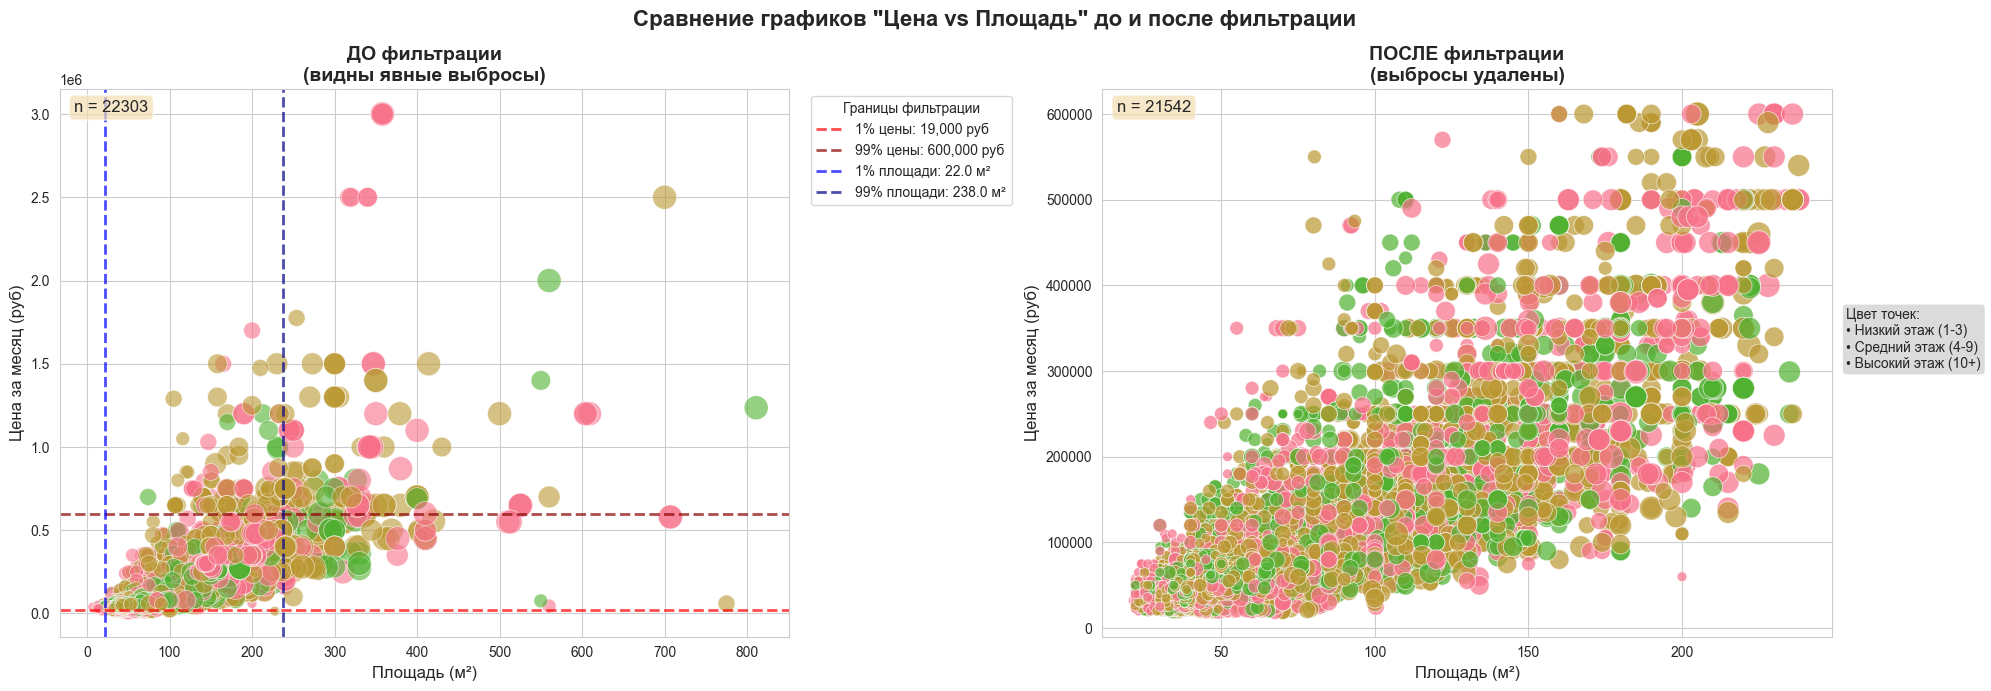


СТАТИСТИКА ПО ГРАНИЦАМ ФИЛЬТРАЦИИ
Цена:
  1-й перцентиль: 19,000 руб. (все что ниже - выбросы)
  99-й перцентиль: 600,000 руб. (все что выше - выбросы)
  Диапазон нормальных цен: 581,000 руб.

Площадь:
  1-й перцентиль: 22.0 м² (все что меньше - выбросы)
  99-й перцентиль: 238.0 м² (все что больше - выбросы)
  Диапазон нормальных площадей: 216.0 м²

КОЛИЧЕСТВО ВЫБРОСОВ:
  По цене (слишком дешево): 214
  По цене (слишком дорого): 210
  По площади (слишком маленькие): 223
  По площади (слишком большие): 223


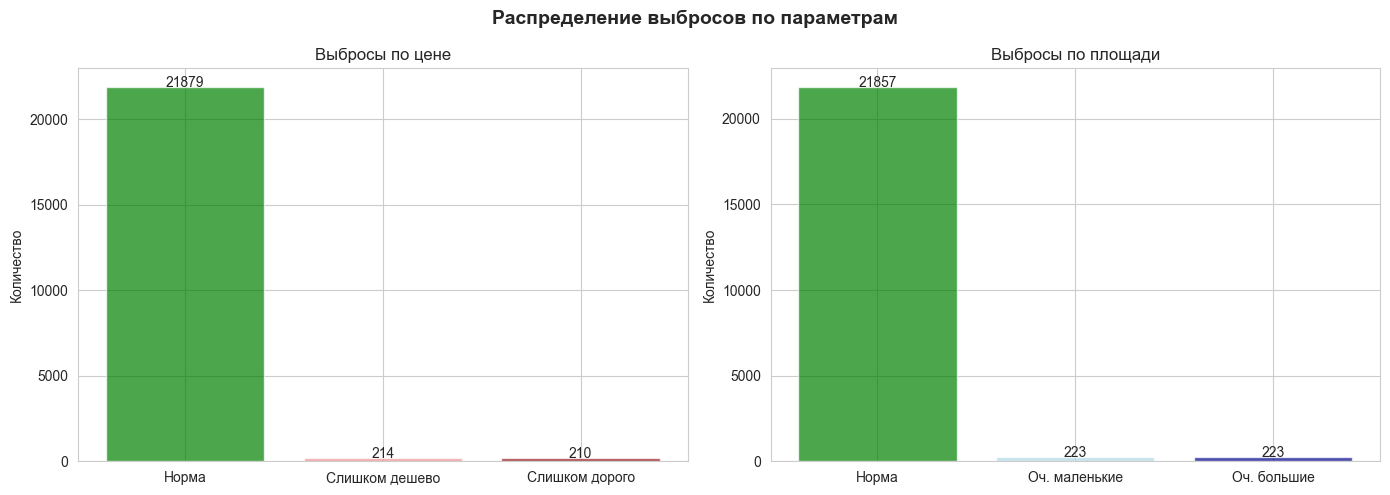

In [4]:
# ============= ГРАФИКИ SCATTER PLOT РЯДОМ (ДО и ПОСЛЕ) =============
print("\n" + "=" * 50)
print("СРАВНЕНИЕ SCATTER PLOT: ДО vs ПОСЛЕ ФИЛЬТРАЦИИ")
print("=" * 50)

# Настройка стиля seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(
    'Сравнение графиков "Цена vs Площадь" до и после фильтрации',
    fontsize=16,
    fontweight="bold",
)

# Добавляем промежуток между графиками
plt.subplots_adjust(wspace=0.3)

# ===== ГРАФИК ДО ФИЛЬТРАЦИИ (слева) =====
scatter1 = sns.scatterplot(
    data=df_clean,
    x="Площадь",
    y="Цена_месяц",
    hue="Тип_этажа",
    size="Комнат",
    sizes=(50, 300),
    alpha=0.6,
    ax=axes[0],
    legend=False,  # Отключаем легенду полностью
)

# Добавляем линии границ
line1 = axes[0].axhline(
    y=price_p1,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label=f"1% цены: {price_p1:,.0f} руб",
)
line2 = axes[0].axhline(
    y=price_p99,
    color="darkred",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label=f"99% цены: {price_p99:,.0f} руб",
)
line3 = axes[0].axvline(
    x=area_p1,
    color="blue",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label=f"1% площади: {area_p1:.1f} м²",
)
line4 = axes[0].axvline(
    x=area_p99,
    color="darkblue",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label=f"99% площади: {area_p99:.1f} м²",
)

axes[0].set_title(
    "ДО фильтрации\n(видны явные выбросы)", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("Площадь (м²)", fontsize=12)
axes[0].set_ylabel("Цена за месяц (руб)", fontsize=12)

# Создаем легенду ТОЛЬКО для линий
from matplotlib.lines import Line2D

line_handles = [
    Line2D([0], [0], color="red", linestyle="--", linewidth=2, alpha=0.7),
    Line2D([0], [0], color="darkred", linestyle="--", linewidth=2, alpha=0.7),
    Line2D([0], [0], color="blue", linestyle="--", linewidth=2, alpha=0.7),
    Line2D([0], [0], color="darkblue", linestyle="--", linewidth=2, alpha=0.7),
]
line_labels = [
    f"1% цены: {price_p1:,.0f} руб",
    f"99% цены: {price_p99:,.0f} руб",
    f"1% площади: {area_p1:.1f} м²",
    f"99% площади: {area_p99:.1f} м²",
]

# Добавляем только легенду для линий
axes[0].legend(
    line_handles,
    line_labels,
    title="Границы фильтрации",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

# Добавляем информацию о количестве записей
axes[0].text(
    0.02,
    0.98,
    f"n = {len(df_clean)}",
    transform=axes[0].transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7),
)

# ===== ГРАФИК ПОСЛЕ ФИЛЬТРАЦИИ (справа) =====
scatter2 = sns.scatterplot(
    data=df_clean_filtered,
    x="Площадь",
    y="Цена_месяц",
    hue="Тип_этажа",
    size="Комнат",
    sizes=(50, 300),
    alpha=0.7,
    ax=axes[1],
    legend=False,  # Отключаем легенду
)

axes[1].set_title("ПОСЛЕ фильтрации\n(выбросы удалены)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Площадь (м²)", fontsize=12)
axes[1].set_ylabel("Цена за месяц (руб)", fontsize=12)

# Добавляем информацию о количестве записей
axes[1].text(
    0.02,
    0.98,
    f"n = {len(df_clean_filtered)}",
    transform=axes[1].transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7),
)

# Добавляем пояснение по цветам в виде текста (опционально)
color_text = (
    "Цвет точек:\n• Низкий этаж (1-3)\n• Средний этаж (4-9)\n• Высокий этаж (10+)"
)
axes[1].text(
    1.02,
    0.6,
    color_text,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.8),
)

plt.tight_layout()
plt.show()

# ===== ДОПОЛНИТЕЛЬНО: Статистика по границам =====
print("\n" + "=" * 50)
print("СТАТИСТИКА ПО ГРАНИЦАМ ФИЛЬТРАЦИИ")
print("=" * 50)
print(f"Цена:")
print(f"  1-й перцентиль: {price_p1:,.0f} руб. (все что ниже - выбросы)")
print(f"  99-й перцентиль: {price_p99:,.0f} руб. (все что выше - выбросы)")
print(f"  Диапазон нормальных цен: {price_p99 - price_p1:,.0f} руб.")
print(f"\nПлощадь:")
print(f"  1-й перцентиль: {area_p1:.1f} м² (все что меньше - выбросы)")
print(f"  99-й перцентиль: {area_p99:.1f} м² (все что больше - выбросы)")
print(f"  Диапазон нормальных площадей: {area_p99 - area_p1:.1f} м²")

# Подсчет выбросов
outliers_price_low = len(df_clean[df_clean["Цена_месяц"] < price_p1])
outliers_price_high = len(df_clean[df_clean["Цена_месяц"] > price_p99])
outliers_area_low = len(df_clean[df_clean["Площадь"] < area_p1])
outliers_area_high = len(df_clean[df_clean["Площадь"] > area_p99])

print(f"\nКОЛИЧЕСТВО ВЫБРОСОВ:")
print(f"  По цене (слишком дешево): {outliers_price_low}")
print(f"  По цене (слишком дорого): {outliers_price_high}")
print(f"  По площади (слишком маленькие): {outliers_area_low}")
print(f"  По площади (слишком большие): {outliers_area_high}")

# Добавляем визуализацию распределения выбросов
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Распределение выбросов по параметрам", fontsize=14, fontweight="bold")

# Выбросы по цене
categories = ["Норма", "Слишком дешево", "Слишком дорого"]
values = [
    len(df_clean) - outliers_price_low - outliers_price_high,
    outliers_price_low,
    outliers_price_high,
]
colors = ["green", "lightcoral", "darkred"]
axes2[0].bar(categories, values, color=colors, alpha=0.7)
axes2[0].set_title("Выбросы по цене")
axes2[0].set_ylabel("Количество")
for i, v in enumerate(values):
    axes2[0].text(i, v + 5, str(v), ha="center")

# Выбросы по площади
categories = ["Норма", "Оч. маленькие", "Оч. большие"]
values = [
    len(df_clean) - outliers_area_low - outliers_area_high,
    outliers_area_low,
    outliers_area_high,
]
colors = ["green", "lightblue", "darkblue"]
axes2[1].bar(categories, values, color=colors, alpha=0.7)
axes2[1].set_title("Выбросы по площади")
axes2[1].set_ylabel("Количество")
for i, v in enumerate(values):
    axes2[1].text(i, v + 5, str(v), ha="center")

plt.tight_layout()
plt.show()


СРАВНЕНИЕ КОРРЕЛЯЦИОННЫХ МАТРИЦ: ДО vs ПОСЛЕ


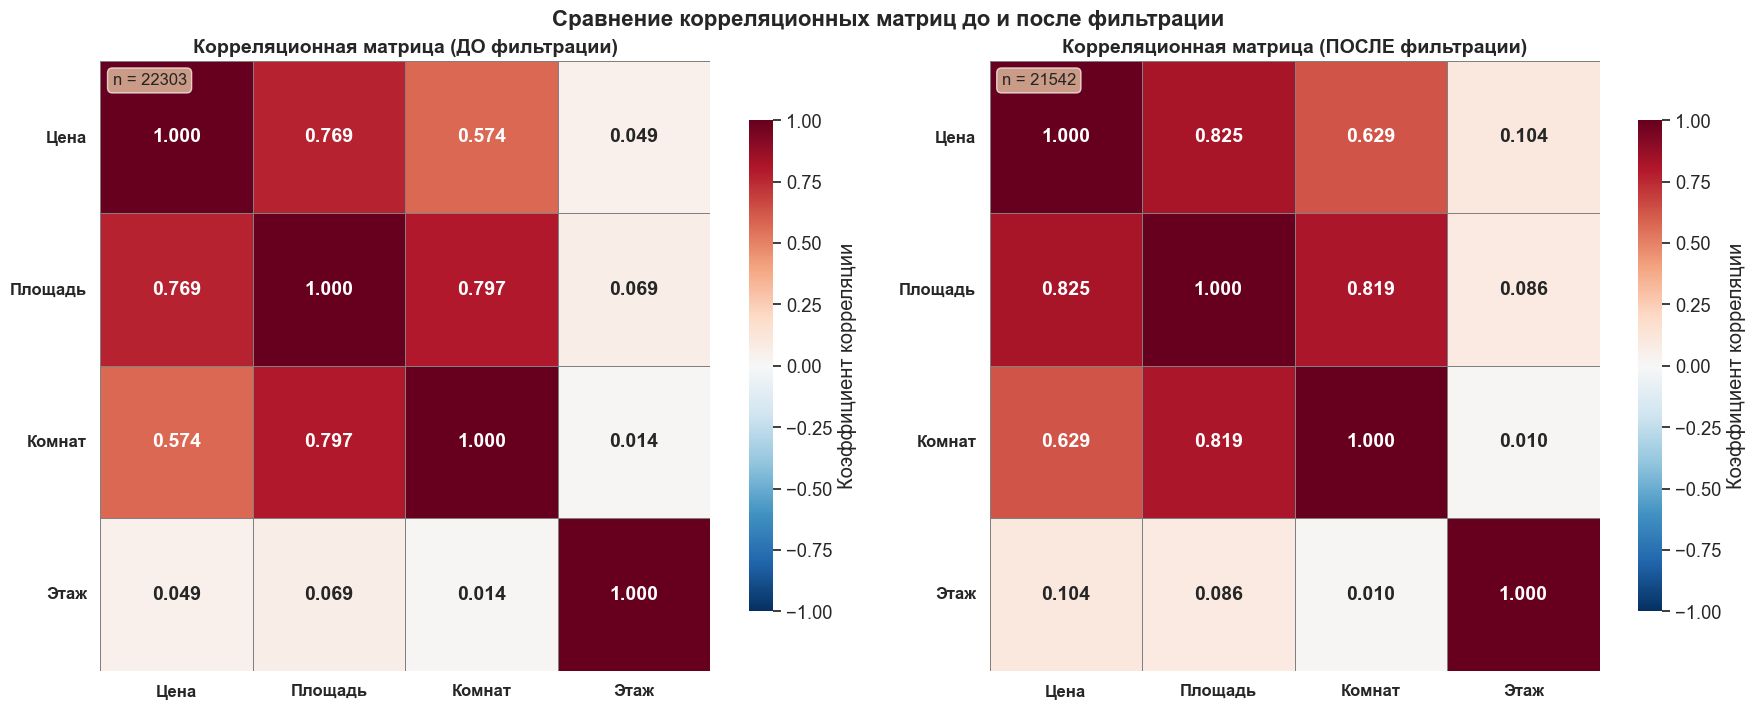


СРАВНЕНИЕ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ
             Пара До фильтрации После фильтрации Изменение
  Цена vs Площадь         0.769            0.825     0.056
   Цена vs Комнат         0.574            0.629     0.055
     Цена vs Этаж         0.049            0.104     0.055
Площадь vs Комнат         0.797            0.819     0.022
  Площадь vs Этаж         0.069            0.086     0.017
   Комнат vs Этаж         0.014            0.010    -0.003

ИНТЕРПРЕТАЦИЯ:
• Положительная корреляция (>0) - при увеличении одного параметра другой растет
• Отрицательная корреляция (<0) - при увеличении одного параметра другой падает
• 0.0-0.3 - слабая связь
• 0.3-0.7 - средняя связь
• 0.7-1.0 - сильная связь

Наибольшее изменение: Цена vs Площадь (+0.056)


In [5]:
# ============= КОРРЕЛЯЦИОННЫЕ МАТРИЦЫ РЯДОМ (ДО и ПОСЛЕ) =============
print("\n" + "=" * 50)
print("СРАВНЕНИЕ КОРРЕЛЯЦИОННЫХ МАТРИЦ: ДО vs ПОСЛЕ")
print("=" * 50)

# Настройка стиля seaborn
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Создаем фигуру с двумя подграфиками
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
fig2.suptitle(
    "Сравнение корреляционных матриц до и после фильтрации",
    fontsize=16,
    fontweight="bold",
)

# Добавляем промежуток между графиками
plt.subplots_adjust(wspace=0.3)

numeric_cols = ["Цена_месяц", "Площадь", "Комнат", "Этаж"]
переменные = ["Цена", "Площадь", "Комнат", "Этаж"]

# ===== КОРРЕЛЯЦИЯ ДО ФИЛЬТРАЦИИ =====
corr_matrix_before = df_clean[numeric_cols].corr()

# Тепловая карта с seaborn
sns.heatmap(
    corr_matrix_before,
    annot=True,
    cmap="RdBu_r",
    center=0,
    square=True,
    ax=axes2[0],
    vmin=-1,
    vmax=1,
    annot_kws={"size": 14, "weight": "bold"},
    fmt=".3f",
    cbar=True,
    cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
    linewidths=0.5,
    linecolor="gray",
)

# Настройка внешнего вида
axes2[0].set_title(
    "Корреляционная матрица (ДО фильтрации)", fontsize=14, fontweight="bold"
)
axes2[0].set_xticklabels(переменные, fontsize=12, fontweight="bold")
axes2[0].set_yticklabels(переменные, fontsize=12, fontweight="bold")
axes2[0].tick_params(axis="x", rotation=0)
axes2[0].tick_params(axis="y", rotation=0)

# Добавляем текст с размером выборки
axes2[0].text(
    0.02,
    0.98,
    f"n = {len(df_clean)}",
    transform=axes2[0].transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7),
)

# ===== КОРРЕЛЯЦИЯ ПОСЛЕ ФИЛЬТРАЦИИ =====
corr_matrix_after = df_clean_filtered[numeric_cols].corr()

# Тепловая карта с seaborn
sns.heatmap(
    corr_matrix_after,
    annot=True,
    cmap="RdBu_r",
    center=0,
    square=True,
    ax=axes2[1],
    vmin=-1,
    vmax=1,
    annot_kws={"size": 14, "weight": "bold"},
    fmt=".3f",
    cbar=True,
    cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
    linewidths=0.5,
    linecolor="gray",
)

# Настройка внешнего вида
axes2[1].set_title(
    "Корреляционная матрица (ПОСЛЕ фильтрации)", fontsize=14, fontweight="bold"
)
axes2[1].set_xticklabels(переменные, fontsize=12, fontweight="bold")
axes2[1].set_yticklabels(переменные, fontsize=12, fontweight="bold")
axes2[1].tick_params(axis="x", rotation=0)
axes2[1].tick_params(axis="y", rotation=0)

# Добавляем текст с размером выборки
axes2[1].text(
    0.02,
    0.98,
    f"n = {len(df_clean_filtered)}",
    transform=axes2[1].transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7),
)

plt.tight_layout()
plt.show()

# ===== ДОПОЛНИТЕЛЬНО: Сравнительная таблица корреляций =====
print("\n" + "=" * 50)
print("СРАВНЕНИЕ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ")
print("=" * 50)

# Сначала собираем данные (как числа)
corr_data = {
    "Пара": [
        "Цена vs Площадь",
        "Цена vs Комнат",
        "Цена vs Этаж",
        "Площадь vs Комнат",
        "Площадь vs Этаж",
        "Комнат vs Этаж",
    ],
    "До фильтрации": [
        corr_matrix_before.loc["Цена_месяц", "Площадь"],
        corr_matrix_before.loc["Цена_месяц", "Комнат"],
        corr_matrix_before.loc["Цена_месяц", "Этаж"],
        corr_matrix_before.loc["Площадь", "Комнат"],
        corr_matrix_before.loc["Площадь", "Этаж"],
        corr_matrix_before.loc["Комнат", "Этаж"],
    ],
    "После фильтрации": [
        corr_matrix_after.loc["Цена_месяц", "Площадь"],
        corr_matrix_after.loc["Цена_месяц", "Комнат"],
        corr_matrix_after.loc["Цена_месяц", "Этаж"],
        corr_matrix_after.loc["Площадь", "Комнат"],
        corr_matrix_after.loc["Площадь", "Этаж"],
        corr_matrix_after.loc["Комнат", "Этаж"],
    ],
}

# Создаем DataFrame
comparison_df = pd.DataFrame(corr_data)

# Вычисляем изменения (работаем с числами)
comparison_df["Изменение"] = (
    comparison_df["После фильтрации"] - comparison_df["До фильтрации"]
)

# Находим самое сильное изменение ДО форматирования
max_change_idx = comparison_df["Изменение"].abs().idxmax()
max_change_value = comparison_df.loc[max_change_idx, "Изменение"]
max_change_pair = comparison_df.loc[max_change_idx, "Пара"]

# Теперь форматируем для красивого вывода
comparison_display = comparison_df.copy()
for col in ["До фильтрации", "После фильтрации", "Изменение"]:
    comparison_display[col] = comparison_display[col].map("{:.3f}".format)

print(comparison_display.to_string(index=False))

print("\n" + "=" * 50)
print("ИНТЕРПРЕТАЦИЯ:")
print("=" * 50)
print("• Положительная корреляция (>0) - при увеличении одного параметра другой растет")
print("• Отрицательная корреляция (<0) - при увеличении одного параметра другой падает")
print("• 0.0-0.3 - слабая связь")
print("• 0.3-0.7 - средняя связь")
print("• 0.7-1.0 - сильная связь")

print(f"\nНаибольшее изменение: {max_change_pair} ({max_change_value:+.3f})")


ВИЗУАЛИЗАЦИЯ УДАЛЕННЫХ ВЫБРОСОВ


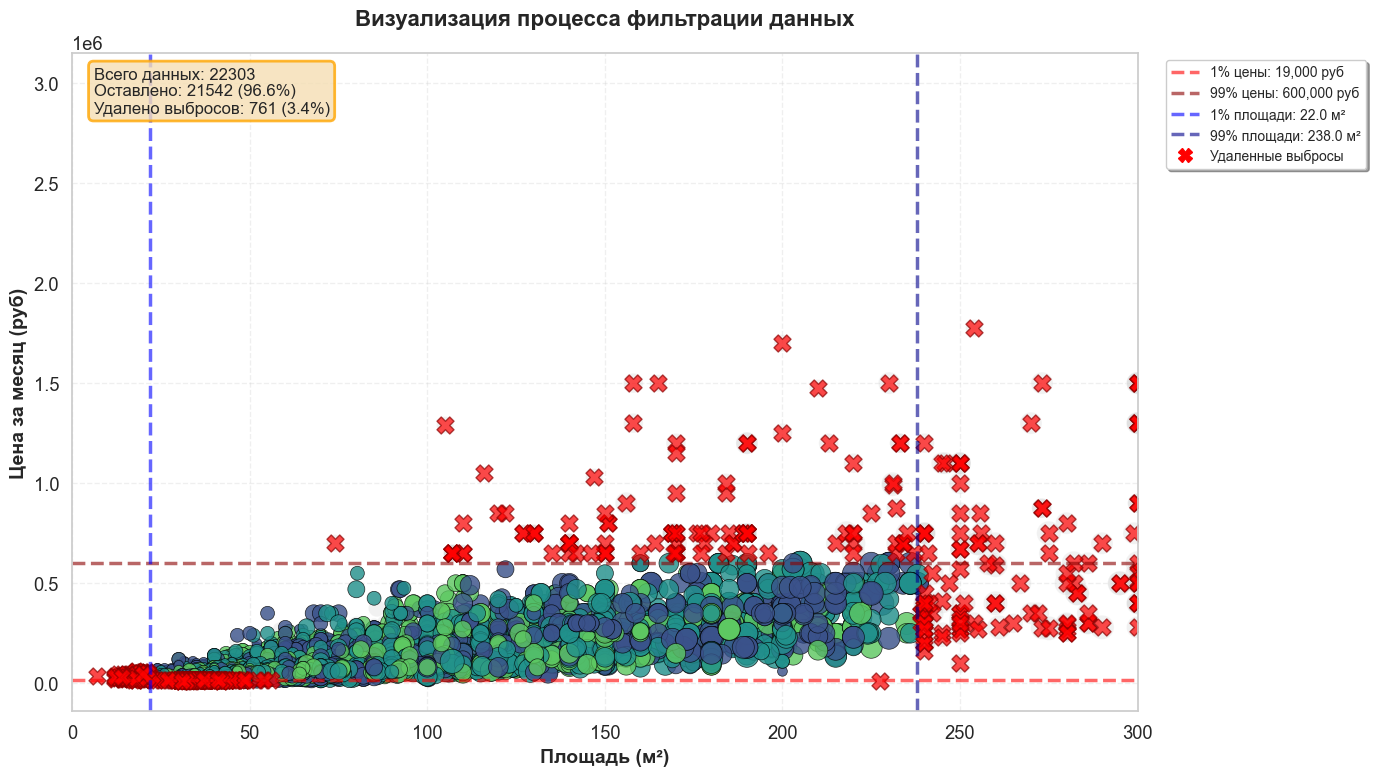


ДЕТАЛЬНАЯ СТАТИСТИКА ПО ВЫБРОСАМ

Всего выбросов: 761

Выбросы по цене:
  • Слишком дешево (< 19,000 руб): 214
  • Слишком дорого (> 600,000 руб): 210

Выбросы по площади:
  • Слишком маленькие (< 22.0 м²): 223
  • Слишком большие (> 238.0 м²): 223


In [6]:
# ============= ДОПОЛНИТЕЛЬНО: ВЫДЕЛЕНИЕ УДАЛЕННЫХ ТОЧЕК =============
print("\n" + "=" * 50)
print("ВИЗУАЛИЗАЦИЯ УДАЛЕННЫХ ВЫБРОСОВ")
print("=" * 50)

# Настройка стиля seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Находим удаленные точки
df_outliers = df_clean[~mask]

# Создаем фигуру
fig3 = plt.figure(figsize=(14, 8))
ax3 = plt.gca()

# Добавляем информацию о количестве
total_points = len(df_clean)
filtered_points = len(df_clean_filtered)
outliers_points = len(df_outliers)
outliers_percent = (outliers_points / total_points) * 100

# 1. Рисуем все точки серым цветом (фон) - через seaborn
sns.scatterplot(
    data=df_clean,
    x="Площадь",
    y="Цена_месяц",
    color="lightgray",
    size="Комнат",
    sizes=(50, 300),
    alpha=0.3,
    ax=ax3,
    label="Все данные (фон)",
    legend=False,
)

# 2. Рисуем оставшиеся после фильтрации точки (цветные) - seaborn стиль
scatter = sns.scatterplot(
    data=df_clean_filtered,
    x="Площадь",
    y="Цена_месяц",
    hue="Тип_этажа",
    size="Комнат",
    sizes=(50, 300),
    alpha=0.8,
    ax=ax3,
    palette="viridis",  # Красивая цветовая палитра
    edgecolor="black",
    linewidth=0.5,
)

# 3. Рисуем удаленные выбросы - seaborn стиль
sns.scatterplot(
    data=df_outliers,
    x="Площадь",
    y="Цена_месяц",
    color="red",
    marker="X",
    s=150,  # Размер крестиков
    alpha=0.7,
    ax=ax3,
    label="Удаленные выбросы",
    edgecolor="darkred",
    linewidth=1,
)

# Добавляем границы фильтрации в стиле seaborn
ax3.axhline(
    y=price_p1,
    color="red",
    linestyle="--",
    linewidth=2.5,
    alpha=0.6,
    label=f"1% цены: {price_p1:,.0f} руб",
)
ax3.axhline(
    y=price_p99,
    color="darkred",
    linestyle="--",
    linewidth=2.5,
    alpha=0.6,
    label=f"99% цены: {price_p99:,.0f} руб",
)
ax3.axvline(
    x=area_p1,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    alpha=0.6,
    label=f"1% площади: {area_p1:.1f} м²",
)
ax3.axvline(
    x=area_p99,
    color="darkblue",
    linestyle="--",
    linewidth=2.5,
    alpha=0.6,
    label=f"99% площади: {area_p99:.1f} м²",
)

# Настройка заголовка и подписей
ax3.set_title(
    "Визуализация процесса фильтрации данных", fontsize=16, fontweight="bold", pad=20
)
ax3.set_xlabel("Площадь (м²)", fontsize=14, fontweight="semibold")
ax3.set_ylabel("Цена за месяц (руб)", fontsize=14, fontweight="semibold")

# Добавляем информационную панель
info_text = (
    f"Всего данных: {total_points}\n"
    f"Оставлено: {filtered_points} ({100 - outliers_percent:.1f}%)\n"
    f"Удалено выбросов: {outliers_points} ({outliers_percent:.1f}%)"
)

ax3.text(
    0.02,
    0.98,
    info_text,
    transform=ax3.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round", facecolor="wheat", alpha=0.8, edgecolor="orange", linewidth=2
    ),
)

# Создаем легенду для линий и выбросов
from matplotlib.lines import Line2D

# Создаем элементы легенды
legend_elements = [
    # Для линий
    Line2D(
        [0],
        [0],
        color="red",
        linestyle="--",
        linewidth=2.5,
        alpha=0.6,
        label=f"1% цены: {price_p1:,.0f} руб",
    ),
    Line2D(
        [0],
        [0],
        color="darkred",
        linestyle="--",
        linewidth=2.5,
        alpha=0.6,
        label=f"99% цены: {price_p99:,.0f} руб",
    ),
    Line2D(
        [0],
        [0],
        color="blue",
        linestyle="--",
        linewidth=2.5,
        alpha=0.6,
        label=f"1% площади: {area_p1:.1f} м²",
    ),
    Line2D(
        [0],
        [0],
        color="darkblue",
        linestyle="--",
        linewidth=2.5,
        alpha=0.6,
        label=f"99% площади: {area_p99:.1f} м²",
    ),
    # Для выбросов
    Line2D(
        [0],
        [0],
        marker="X",
        color="red",
        markerfacecolor="red",
        markersize=10,
        linestyle="None",
        label="Удаленные выбросы",
    ),
]

# Добавляем легенду
ax3.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    frameon=True,
    fancybox=True,
    shadow=True,
)

# Добавляем сетку для лучшей читаемости
ax3.grid(True, alpha=0.3, linestyle="--")

# Настраиваем пределы для лучшего обзора (опционально)
if area_p99 < df_clean["Площадь"].max() * 0.5:  # Если есть очень большие выбросы
    ax3.set_xlim(0, min(area_p99 * 1.5, df_clean["Площадь"].quantile(0.995)))

plt.tight_layout()
plt.show()

# ===== ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА ПО ВЫБРОСАМ =====
print("\n" + "=" * 50)
print("ДЕТАЛЬНАЯ СТАТИСТИКА ПО ВЫБРОСАМ")
print("=" * 50)

# Анализ выбросов по категориям
print(f"\nВсего выбросов: {outliers_points}")

# По цене
price_outliers_low = len(df_clean[df_clean["Цена_месяц"] < price_p1])
price_outliers_high = len(df_clean[df_clean["Цена_месяц"] > price_p99])
print(f"\nВыбросы по цене:")
print(f"  • Слишком дешево (< {price_p1:,.0f} руб): {price_outliers_low}")
print(f"  • Слишком дорого (> {price_p99:,.0f} руб): {price_outliers_high}")

# По площади
area_outliers_low = len(df_clean[df_clean["Площадь"] < area_p1])
area_outliers_high = len(df_clean[df_clean["Площадь"] > area_p99])
print(f"\nВыбросы по площади:")
print(f"  • Слишком маленькие (< {area_p1:.1f} м²): {area_outliers_low}")
print(f"  • Слишком большие (> {area_p99:.1f} м²): {area_outliers_high}")

In [7]:
# ============= СТАТИСТИКА =============
print("\n" + "=" * 50)
print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ")
print("=" * 50)

print("\nСтатистика до фильтрации:")
print(df_clean[["Цена_месяц", "Площадь", "Комнат", "Этаж"]].describe().round(2))

print("\nСтатистика после фильтрации:")
print(
    df_clean_filtered[["Цена_месяц", "Площадь", "Комнат", "Этаж"]].describe().round(2)
)

print("\nИзменение корреляций:")
print(
    f"Корреляция Цена-Площадь: {corr_matrix_before.loc['Цена_месяц', 'Площадь']:.3f} → {corr_matrix_after.loc['Цена_месяц', 'Площадь']:.3f} ({corr_matrix_after.loc['Цена_месяц', 'Площадь'] - corr_matrix_before.loc['Цена_месяц', 'Площадь']:+.3f})"
)
print(
    f"Корреляция Цена-Комнат: {corr_matrix_before.loc['Цена_месяц', 'Комнат']:.3f} → {corr_matrix_after.loc['Цена_месяц', 'Комнат']:.3f} ({corr_matrix_after.loc['Цена_месяц', 'Комнат'] - corr_matrix_before.loc['Цена_месяц', 'Комнат']:+.3f})"
)
print(
    f"Корреляция Площадь-Комнат: {corr_matrix_before.loc['Площадь', 'Комнат']:.3f} → {corr_matrix_after.loc['Площадь', 'Комнат']:.3f} ({corr_matrix_after.loc['Площадь', 'Комнат'] - corr_matrix_before.loc['Площадь', 'Комнат']:+.3f})"
)


СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ

Статистика до фильтрации:
       Цена_месяц   Площадь   Комнат     Этаж
count    22303.00  22303.00  22303.0  22303.0
mean     84953.57     64.20     2.01     7.36
std     125040.16     45.77      1.0     5.83
min      10000.00      7.00      1.0      1.0
25%      38000.00     39.00      1.0      3.0
50%      50000.00     50.00      2.0      6.0
75%      75000.00     70.00      3.0     10.0
max    3000000.00    811.00      6.0     85.0

Статистика после фильтрации:
       Цена_месяц   Площадь   Комнат     Этаж
count    21542.00  21542.00  21542.0  21542.0
mean     75832.52     61.67     1.99      7.4
std      75950.82     35.04     0.94      5.8
min      19000.00     22.00      1.0      1.0
25%      38000.00     39.40      1.0      3.0
50%      50000.00     50.00      2.0      6.0
75%      75000.00     70.00      3.0     10.0
max     600000.00    238.00      6.0     85.0

Изменение корреляций:
Корреляция Цена-Площадь: 0.769 → 0.825 (+0.056)
Корреляция Цена-Ко


ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПО КОМНАТАМ


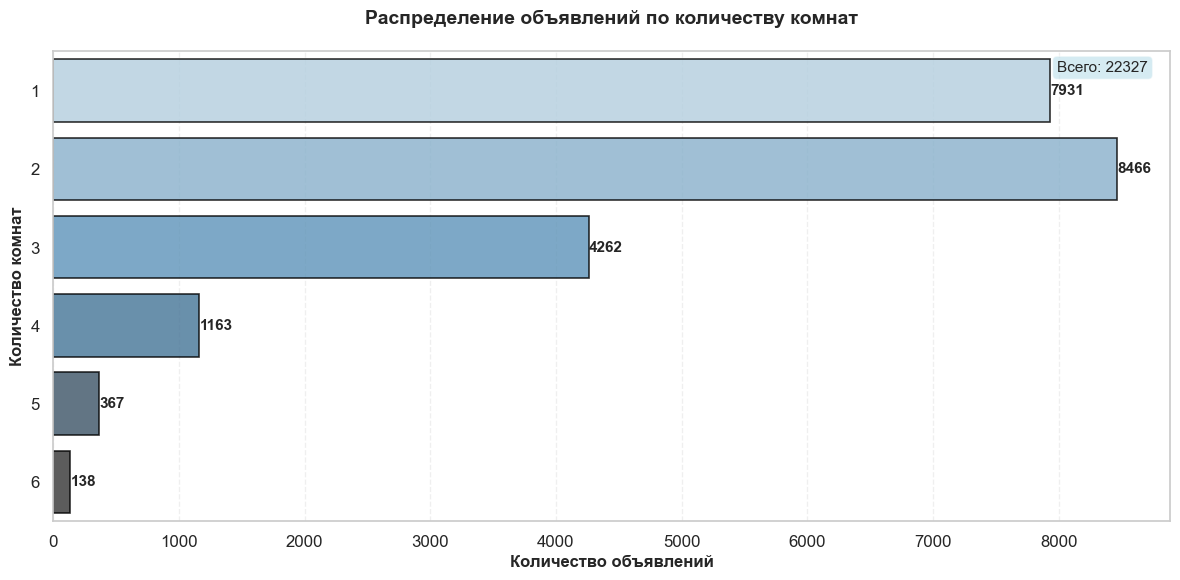


📊 Итого: 22327 объявлений
📈 Среднее количество объявлений на комнату: 3721.2
🏆 Самое популярное: 2 комн.
📉 Самое редкое: 6 комн.


In [8]:
# Ваши очищенные данные
df_clean = pd.DataFrame(
    {
        "Количество комнат": rooms,
        "Цена": price_per_month,
        "Площадь": area,
        "Этаж": floor,
    }
)

# Удаляем пропуски если есть
df_clean = df_clean.dropna(subset=["Количество комнат"])

# Подсчитываем количество объявлений по комнатам
room_counts = df_clean["Количество комнат"].value_counts().sort_index().reset_index()
room_counts.columns = ["Количество комнат", "Количество объявлений"]

# ===== ГОРИЗОНТАЛЬНЫЙ БАРПЛOT В СТИЛЕ SEABORN =====
print("\n" + "=" * 50)
print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПО КОМНАТАМ")
print("=" * 50)

# Настройка стиля seaborn
sns.set_style("whitegrid")
sns.set_palette("Blues_d")
sns.set_context("notebook", font_scale=1.1)

# Создаем фигуру
plt.figure(figsize=(12, 6))

# Горизонтальный барплот в стиле seaborn
ax = sns.barplot(
    data=room_counts,
    y="Количество комнат",
    x="Количество объявлений",
    orient="h",
    palette="Blues_d",  # Цветовая палитра
    edgecolor="black",  # Обводка
    linewidth=1.2,
    alpha=0.8,
    hue="Количество комнат",  # Добавляем hue для градиента
    legend=False,  # Отключаем легенду
)

# Настройка заголовка и подписей
plt.title(
    "Распределение объявлений по количеству комнат",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Количество объявлений", fontsize=12, fontweight="semibold")
plt.ylabel("Количество комнат", fontsize=12, fontweight="semibold")

# Добавляем значения на столбцы (как в вашем коде)
for i, (_, row) in enumerate(room_counts.iterrows()):
    plt.text(
        row["Количество объявлений"] + 0.5,  # позиция по x
        i,  # позиция по y
        f"{int(row['Количество объявлений'])}",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

# Добавляем небольшую сетку для лучшей читаемости
plt.grid(True, alpha=0.3, axis="x", linestyle="--")

# Добавляем общее количество объявлений
total = room_counts["Количество объявлений"].sum()
plt.text(
    0.98,
    0.98,
    f"Всего: {total}",
    transform=ax.transAxes,
    fontsize=11,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.5),
)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print(f"\n📊 Итого: {total} объявлений")
print(f"📈 Среднее количество объявлений на комнату: {total / len(room_counts):.1f}")
print(
    f"🏆 Самое популярное: {int(room_counts.iloc[room_counts['Количество объявлений'].argmax()]['Количество комнат'])} комн."
)
print(
    f"📉 Самое редкое: {int(room_counts.iloc[room_counts['Количество объявлений'].argmin()]['Количество комнат'])} комн."
)

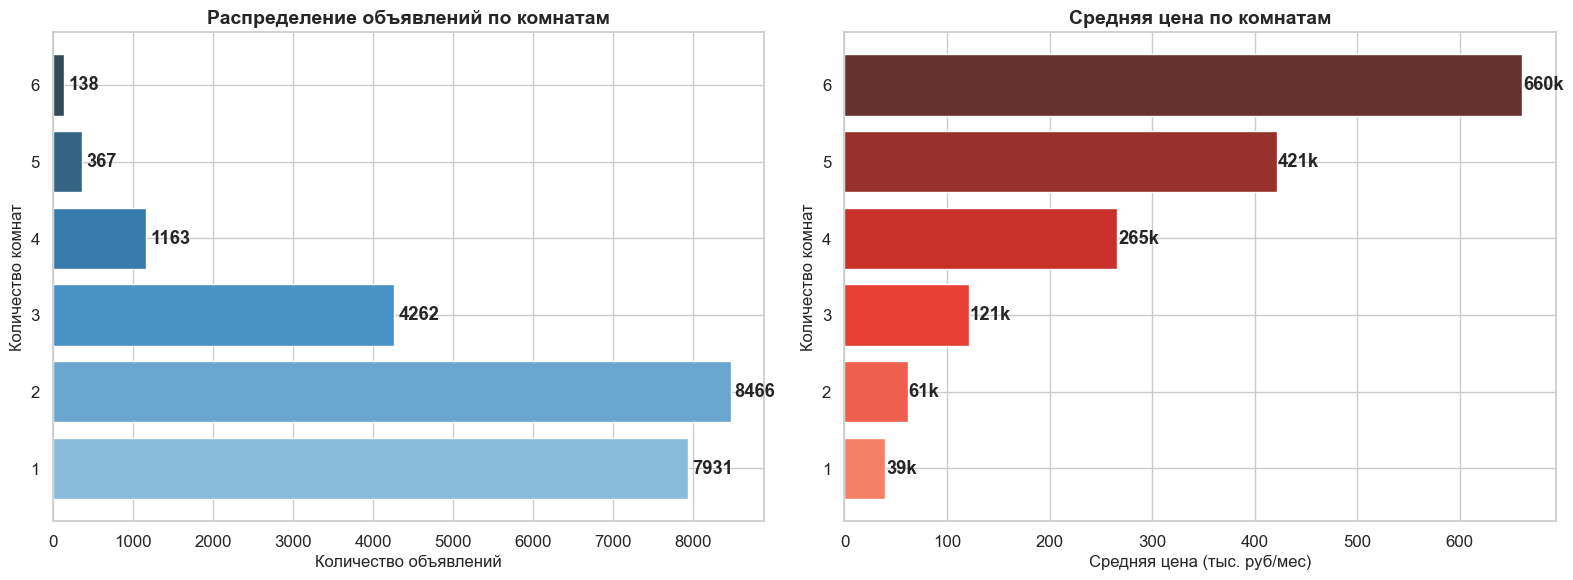

In [9]:
# Группировка по комнатам
room_stats = (
    df_clean.groupby("Количество комнат")
    .agg(
        {"Количество комнат": "count", "Цена": ["mean", "median", "min", "max", "std"]}
    )
    .round(0)
)

# Переименовываем колонки
room_stats.columns = [
    "Количество объявлений",
    "Ср. цена",
    "Мед. цена",
    "Мин. цена",
    "Макс. цена",
    "Стд. откл.",
]
room_stats = room_stats.reset_index()

# Создаем график
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Настройка стиля
sns.set_style("whitegrid")

# 1. Горизонтальный барплот (количество объявлений)
ax1 = axes[0]
colors1 = sns.color_palette("Blues_d", len(room_stats))
bars1 = ax1.barh(
    room_stats["Количество комнат"].astype(str),
    room_stats["Количество объявлений"],
    color=colors1,
)
ax1.set_xlabel("Количество объявлений", fontsize=12)
ax1.set_ylabel("Количество комнат", fontsize=12)
ax1.set_title("Распределение объявлений по комнатам", fontsize=14, fontweight="bold")

# Добавляем значения
for i, (_, row) in enumerate(room_stats.iterrows()):
    ax1.text(
        row["Количество объявлений"] + 50,
        i,
        f"{int(row['Количество объявлений'])}",
        va="center",
        fontweight="bold",
    )

# 2. Горизонтальный барплот (средняя цена)
ax2 = axes[1]
colors2 = sns.color_palette("Reds_d", len(room_stats))
bars2 = ax2.barh(
    room_stats["Количество комнат"].astype(str),
    room_stats["Ср. цена"] / 1000,  # в тысячах для читаемости
    color=colors2,
)
ax2.set_xlabel("Средняя цена (тыс. руб/мес)", fontsize=12)
ax2.set_ylabel("Количество комнат", fontsize=12)
ax2.set_title("Средняя цена по комнатам", fontsize=14, fontweight="bold")

# Добавляем значения
for i, (_, row) in enumerate(room_stats.iterrows()):
    ax2.text(
        row["Ср. цена"] / 1000 + 1,
        i,
        f"{int(row['Ср. цена'] / 1000)}k",
        va="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()